/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


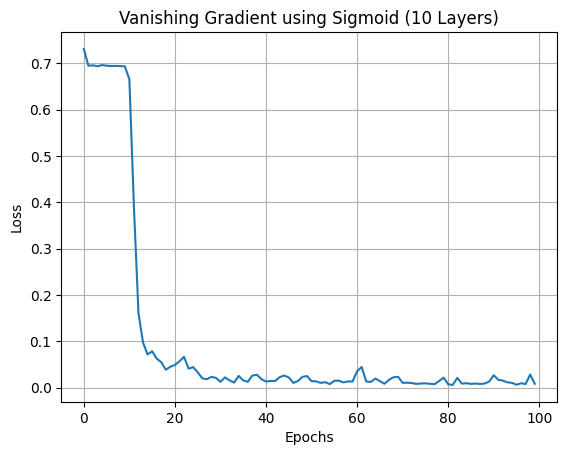

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split


np.random.seed(42)


X = np.random.randn(2000, 2)
y = (X[:, 0] + X[:, 1] > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = Sequential()

model.add(Dense(32, activation='sigmoid', input_shape=(2,)))  # Layer 1

for _ in range(8):                                            # Layers 2–9
    model.add(Dense(32, activation='sigmoid'))

model.add(Dense(1, activation='sigmoid'))                     # Layer 10


model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy'
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    verbose=0
)

# Plot loss
plt.plot(history.history['loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Vanishing Gradient using Sigmoid (10 Layers)")
plt.grid()
plt.show()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1017 - loss: 2.4359
Epoch 2/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1018 - loss: 2.3280
Epoch 3/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1127 - loss: 2.3069
Epoch 4/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1127 - loss: 2.3025
Epoch 5/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1127 - loss: 2.3015
Epoch 6/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1127 - loss: 2.3013
Epoch 7/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1127 - loss: 2.3013
Epoch 8/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1127 - loss: 2.3013
Epoch 9/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1127 - loss: 2.3013
Epoch 10/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1127 - loss: 2.3013
Epoch 11/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1127 - loss: 2.3013
Epoch 12/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

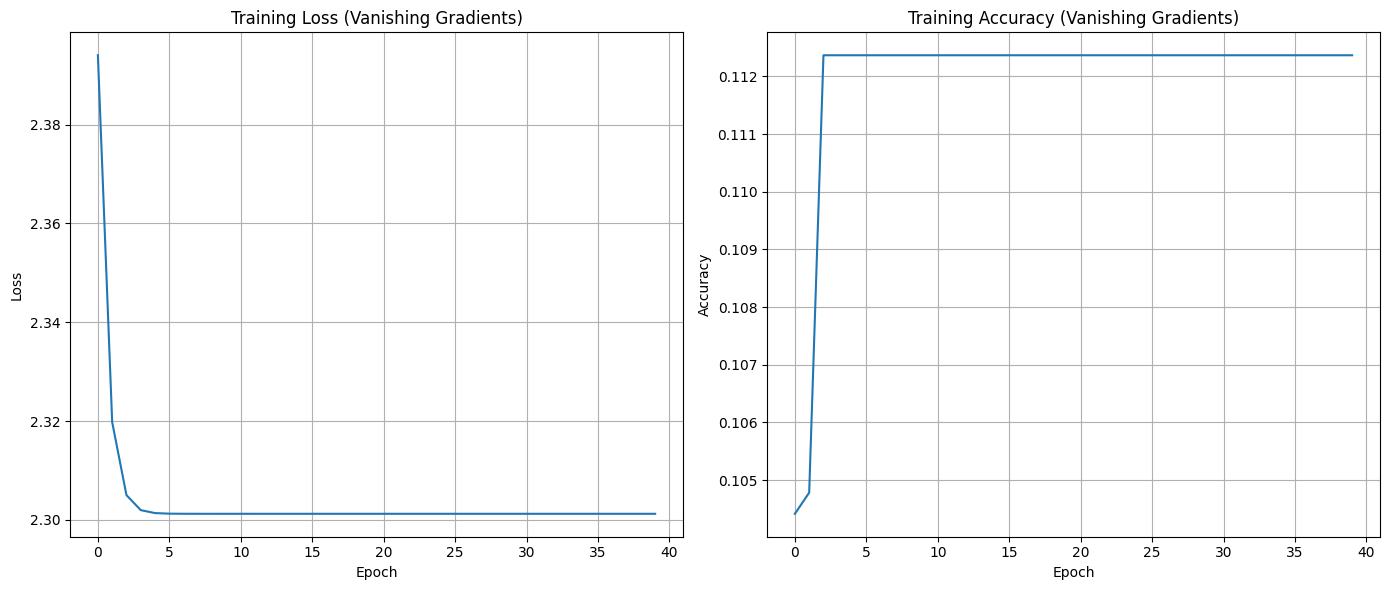

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, optimizers, initializers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

tf.random.set_seed(42)
np.random.seed(42)

(X_train, y_train), _ = mnist.load_data()
X_train = X_train.astype("float32") / 255.0
X_train = X_train.reshape(X_train.shape[0], -1)
y_train = to_categorical(y_train, 10)

init1 = initializers.RandomNormal(mean=0.0, stddev=0.1)
init2 = initializers.RandomNormal(mean=0.0, stddev=0.001)

model = models.Sequential()
model.add(layers.Dense(128, activation="sigmoid",
                       kernel_initializer=init1,
                       input_shape=(784,)))

for _ in range(3):
    model.add(layers.Dense(64,
                           activation="sigmoid",
                           kernel_initializer=init2))

model.add(layers.Dense(10, activation="softmax"))

model.compile(
    optimizer=optimizers.SGD(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=128,
    verbose=1
)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"])
plt.title("Training Loss (Vanishing Gradients)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"])
plt.title("Training Accuracy (Vanishing Gradients)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)

plt.tight_layout()
plt.show()


Epoch 1/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1086 - loss: 1285707184209920.0000
Epoch 2/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1077 - loss: 2.3026
Epoch 3/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1077 - loss: 2.3026
Epoch 4/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1077 - loss: 2.3026
Epoch 5/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1077 - loss: 2.3026
Epoch 6/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1077 - loss: 2.3026
Epoch 7/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1077 - loss: 2.3026
Epoch 8/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1077 - loss: 2.3026
Epoch 9/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1077 - loss: 2.3026
Epoch 10/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1077 - loss: 2.3026
Epoch 11/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1077 - loss: 2.3026
Epoch 12/40
469/469 ━━━━━━━━━━━━━━━━━

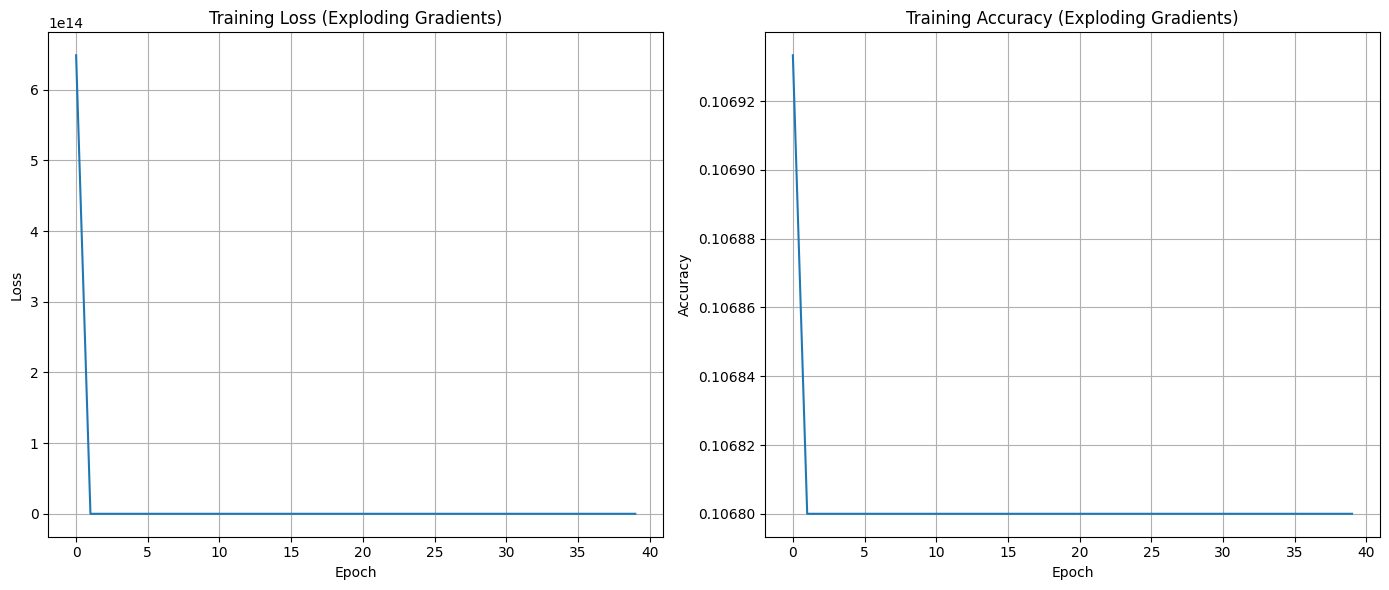

In [ ]:
# exploding gradients
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, optimizers, initializers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

tf.random.set_seed(42)
np.random.seed(42)

(X_train, y_train), _ = mnist.load_data()
X_train = X_train.astype("float32") / 255.0
X_train = X_train.reshape(X_train.shape[0], -1)
y_train = to_categorical(y_train, 10)

big_init = initializers.RandomNormal(mean=0.0, stddev=5.0)

model = models.Sequential()
model.add(layers.Dense(128,
                       activation="relu",
                       kernel_initializer=big_init,
                       input_shape=(784,)))
model.add(layers.Dense(64,
                       activation="relu",
                       kernel_initializer=big_init))
model.add(layers.Dense(10, activation="softmax"))

model.compile(
    optimizer=optimizers.SGD(learning_rate=0.8),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=128,
    verbose=1
)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"])
plt.title("Training Loss (Exploding Gradients)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"])
plt.title("Training Accuracy (Exploding Gradients)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)

plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3796 - loss: 1.8411
Epoch 2/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8568 - loss: 0.5370
Epoch 3/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9322 - loss: 0.2682
Epoch 4/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9523 - loss: 0.1837
Epoch 5/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9632 - loss: 0.1419
Epoch 6/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9699 - loss: 0.1158
Epoch 7/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9754 - loss: 0.0971
Epoch 8/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9791 - loss: 0.0824
Epoch 9/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9822 - loss: 0.0704
Epoch 10/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9853 - loss: 0.0604
Epoch 11/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9877 - loss: 0.0516
Epoch 12/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

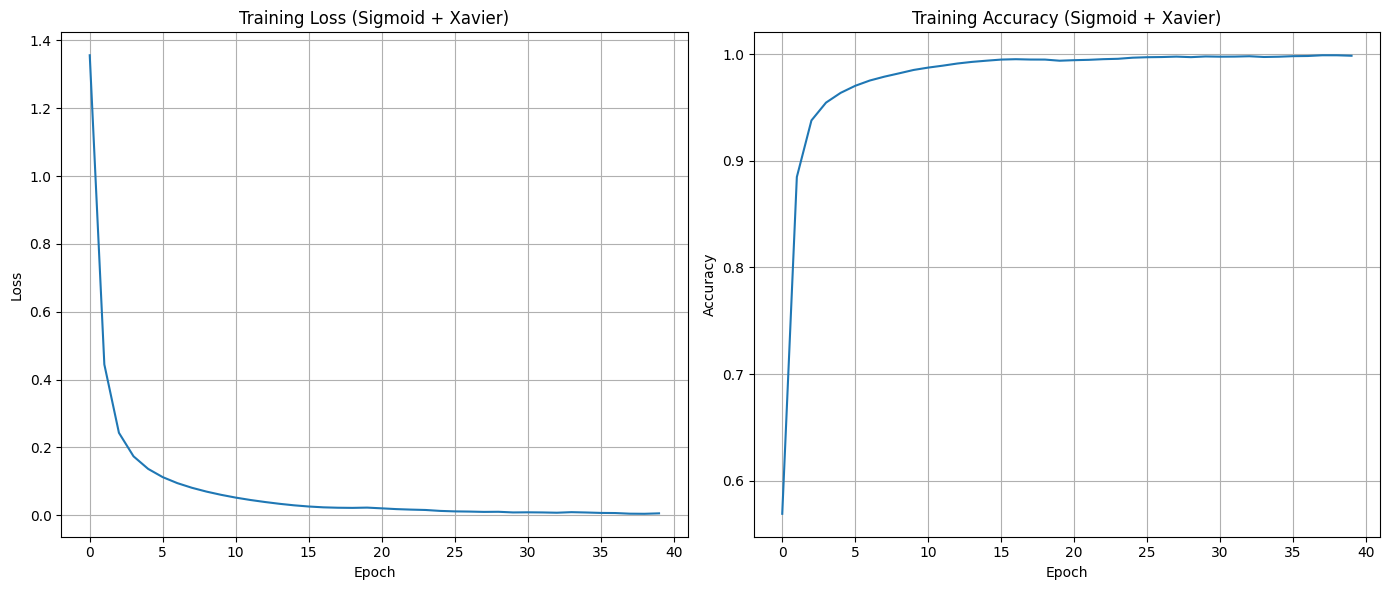

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.initializers import GlorotNormal
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

tf.random.set_seed(42)
np.random.seed(42)

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

X_train = X_train.reshape(-1, 784)
X_test  = X_test.reshape(-1, 784)

y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

xavier = GlorotNormal()

model = Sequential([
    Dense(96,
          activation="sigmoid",
          kernel_initializer=xavier,
          input_shape=(784,)),

    Dense(96,
          activation="sigmoid",
          kernel_initializer=xavier),

    Dense(48,
          activation="sigmoid",
          kernel_initializer=xavier),

    Dense(48,
          activation="sigmoid",
          kernel_initializer=xavier),

    Dense(10, activation="softmax")
])

model.compile(
    optimizer="Adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=128,
    verbose=1
)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"])
plt.title("Training Loss (Sigmoid + Xavier)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"])
plt.title("Training Accuracy (Sigmoid + Xavier)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)

plt.tight_layout()
plt.show()


Epoch 1/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8085 - loss: 0.6224
Epoch 2/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9608 - loss: 0.1307
Epoch 3/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9742 - loss: 0.0864
Epoch 4/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9810 - loss: 0.0627
Epoch 5/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9836 - loss: 0.0517
Epoch 6/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9873 - loss: 0.0399
Epoch 7/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9888 - loss: 0.0361
Epoch 8/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9907 - loss: 0.0290
Epoch 9/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9902 - loss: 0.0292
Epoch 10/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9926 - loss: 0.0238
Epoch 11/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9925 - loss: 0.0226
Epoch 12/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

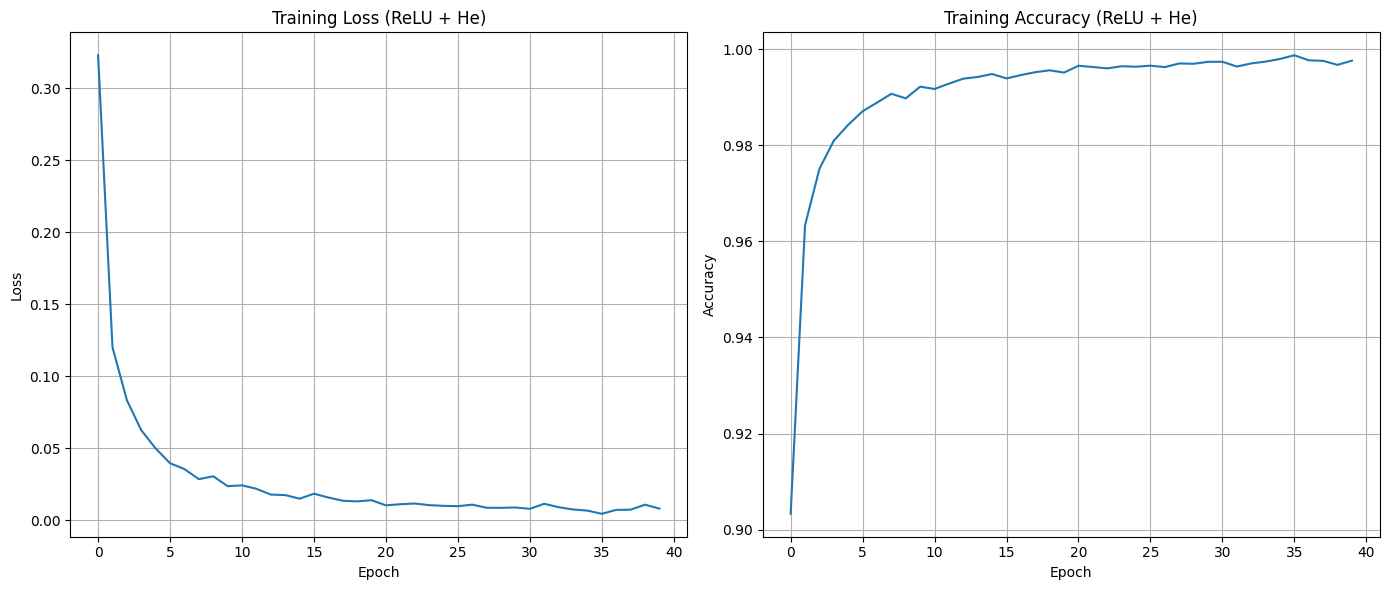

In [ ]:
# he + relu
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

tf.random.set_seed(42)
np.random.seed(42)

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

X_train = X_train.reshape(-1, 784)
X_test  = X_test.reshape(-1, 784)

y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

he = HeNormal()

model = Sequential([
    Dense(120,
          activation="relu",
          kernel_initializer=he,
          input_shape=(784,)),

    Dense(64,
          activation="relu",
          kernel_initializer=he),

    Dense(64,
          activation="relu",
          kernel_initializer=he),

    Dense(48,
          activation="relu",
          kernel_initializer=he),

    Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=128,
    verbose=1
)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"])
plt.title("Training Loss (ReLU + He)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"])
plt.title("Training Accuracy (ReLU + He)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)

plt.tight_layout()
plt.show()


Epoch 1/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4853 - loss: 1.6477
Epoch 2/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8761 - loss: 0.4332
Epoch 3/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9064 - loss: 0.3226
Epoch 4/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9199 - loss: 0.2736
Epoch 5/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9290 - loss: 0.2413
Epoch 6/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9368 - loss: 0.2170
Epoch 7/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9429 - loss: 0.1975
Epoch 8/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9482 - loss: 0.1812
Epoch 9/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9523 - loss: 0.1677
Epoch 10/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9551 - loss: 0.1561
Epoch 11/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9575 - loss: 0.1462
Epoch 12/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

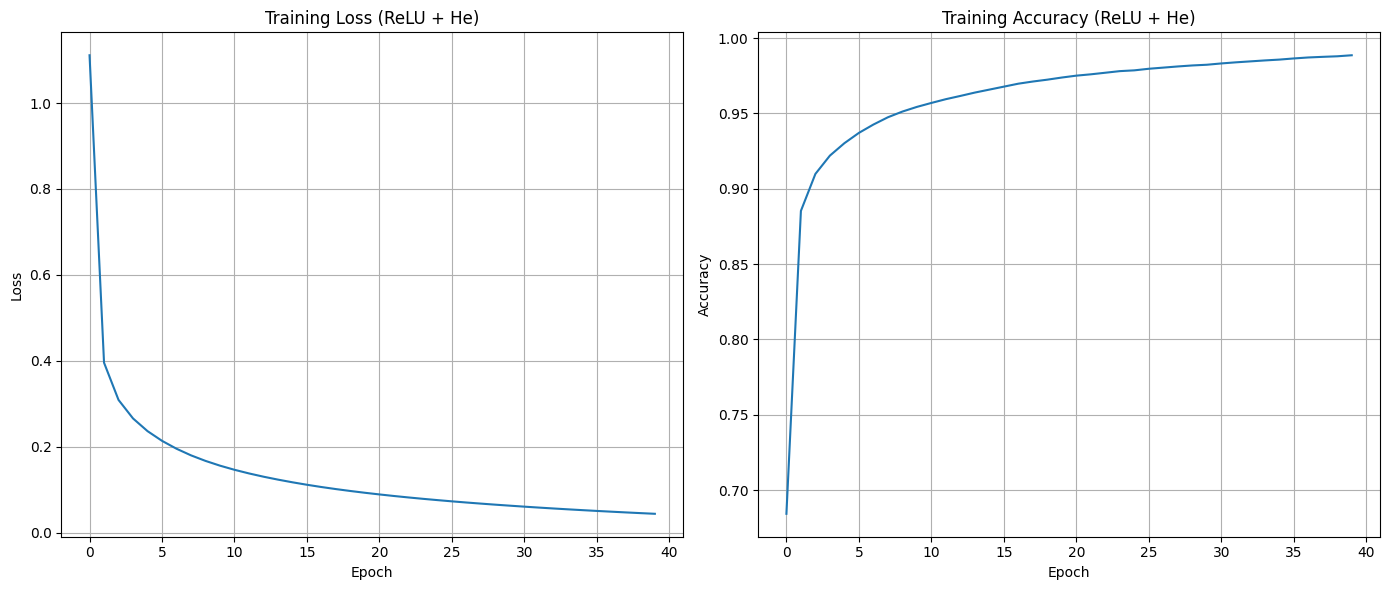

In [ ]:
# he + relu with SGD
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

tf.random.set_seed(42)
np.random.seed(42)

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

X_train = X_train.reshape(-1, 784)
X_test  = X_test.reshape(-1, 784)

y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

he = HeNormal()

model = Sequential([
    Dense(120,
          activation="relu",
          kernel_initializer=he,
          input_shape=(784,)),

    Dense(64,
          activation="relu",
          kernel_initializer=he),

    Dense(64,
          activation="relu",
          kernel_initializer=he),

    Dense(32,
          activation="relu",
          kernel_initializer=he),

    Dense(10, activation="softmax")
])

model.compile(
    optimizer="SGD",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=128,
    verbose=1
)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"])
plt.title("Training Loss (ReLU + He)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"])
plt.title("Training Accuracy (ReLU + He)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)

plt.tight_layout()
plt.show()
